In [6]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [7]:
path="/Users/mattgonzales/downloads/Labeled Turnips - turnip_weekly_clean.csv"
turnip=pd.read_csv(path)

In [8]:
turnip = turnip.dropna()
turnip.isna().sum()

week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [9]:
OriginalTurnips = turnip.copy()
OriginalTurnips = OriginalTurnips.drop("week", axis=1)
TurnipLabel = turnip["Label"]
turnip=turnip.drop(["week", "Label"], axis=1)
feature_names = turnip.columns
print(OriginalTurnips)
print(turnip)

     Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
0         96.0       92.0       87.0        82.0          79            74   
1        109.0       88.0       84.0        80.0          76            73   
2        106.0       96.0       91.0        86.0          83            79   
4        107.0       80.0       99.0       123.0         168           183   
6         96.0       86.0       83.0       132.0         139           512   
..         ...        ...        ...         ...         ...           ...   
105      110.0       98.0       94.0        90.0          86            81   
106      108.0      141.0      110.0       151.0         115           144   
107      106.0      103.0       77.0        69.0          64           117   
108      103.0      110.0      138.0       118.0         108           144   
109       93.0       75.0       66.0        58.0         129            98   

     Wednesday_PM  Thursday_AM  Thursday_PM  Friday_AM  Friday_

In [10]:
bins = [0, 79, 119, 149, 1000]
labels = ['Low_Price', 'Mid_Price', 'High_Mid_Price', 'High_Price']
turnip_binned = turnip.copy()
for col in turnip.columns:
    turnip_binned[col] = pd.cut(turnip[col],
                            bins=bins,
                            labels=labels,
                            include_lowest=True)

In [11]:
turnip_binned

,Sunday_AM,Monday_AM,Monday_PM,Tuesday_AM,Tuesday_PM,Wednesday_AM,Wednesday_PM,Thursday_AM,Thursday_PM,Friday_AM,Friday_PM,Saturday_AM,Saturday_PM
0,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Mid_Price,Mid_Price,High_Price,High_Price,High_Price,Mid_Price,Mid_Price
1,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Low_Price,Mid_Price,High_Mid_Price,High_Price,High_Price,High_Price
2,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price
4,Mid_Price,Mid_Price,Mid_Price,High_Mid_Price,High_Price,High_Price,High_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price
6,Mid_Price,Mid_Price,Mid_Price,High_Mid_Price,High_Mid_Price,High_Price,High_Price,Mid_Price,Low_Price,Low_Price,Mid_Price,Low_Price,Low_Price
...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price,Low_Price
106,Mid_Price,High_Mid_Price,Mid_Price,High_Price,Mid_Price,High_Mid_Price,High_Mid_Price,Low_Price,Low_Price,Low_Price,High_Mid_Price,Low_Price,Low_Price
107,Mid_Price,Mid_Price,Low_Price,Low_Price,Low_Price,Mid_Price,Mid_Price,Mid_Price,Low_Price,Mid_Price,High_Mid_Price,Mid_Price,High_Mid_Price
108,Mid_Price,Mid_Price,High_Mid_Price,Mid_Price,Mid_Price,High_Mid_Price,Low_Price,Low_Price,Mid_Price,High_Mid_Price,Low_Price,Low_Price,Low_Price


In [12]:
transactions = turnip_binned.apply(lambda row: row.dropna().tolist(), axis=1).tolist()

In [13]:
te = TransactionEncoder()
df_encoded = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)
df_encoded

,High_Mid_Price,High_Price,Low_Price,Mid_Price
0,False,True,True,True
1,True,True,True,True
2,False,False,True,True
3,True,True,True,True
4,True,True,True,True
...,...,...,...,...
99,False,False,True,True
100,True,True,True,True
101,True,False,True,True
102,True,False,True,True


In [14]:
frequent_itemsets = apriori(df_encoded, min_support=0.25, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.25)
rules = rules[rules['antecedents'].apply(len) + rules['consequents'].apply(len) >= 2]
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].reset_index(drop=True)

In [15]:
print("=" * 60)
print("TOP 15 RULES BY SUPPORT")
print("=" * 60)
print(rules.nlargest(15, 'support').to_string(index=False))

TOP 15 RULES BY SUPPORT
                antecedents                 consequents  support  confidence  lift
                (Low_Price)                 (Mid_Price) 1.000000    1.000000   1.0
                (Mid_Price)                 (Low_Price) 1.000000    1.000000   1.0
                (Low_Price)            (High_Mid_Price) 0.663462    0.663462   1.0
           (High_Mid_Price)                 (Low_Price) 0.663462    1.000000   1.0
                (Mid_Price)            (High_Mid_Price) 0.663462    0.663462   1.0
           (High_Mid_Price)                 (Mid_Price) 0.663462    1.000000   1.0
(Low_Price, High_Mid_Price)                 (Mid_Price) 0.663462    1.000000   1.0
     (Low_Price, Mid_Price)            (High_Mid_Price) 0.663462    0.663462   1.0
(Mid_Price, High_Mid_Price)                 (Low_Price) 0.663462    1.000000   1.0
                (Low_Price) (Mid_Price, High_Mid_Price) 0.663462    0.663462   1.0
           (High_Mid_Price)      (Low_Price, Mid_Price) 0.66346

In [26]:
print("=" * 60)
print("TOP 15 RULES BY LIFT")
print("=" * 60)
print(rules.nlargest(15, 'lift').to_string(index=False))

TOP 15 RULES BY LIFT
                           antecedents                 consequents  support  confidence     lift
                          (High_Price)            (High_Mid_Price) 0.423077    0.785714 1.184265
                      (High_Mid_Price)                (High_Price) 0.423077    0.637681 1.184265
               (Low_Price, High_Price)            (High_Mid_Price) 0.423077    0.785714 1.184265
           (Low_Price, High_Mid_Price)                (High_Price) 0.423077    0.637681 1.184265
                          (High_Price) (Low_Price, High_Mid_Price) 0.423077    0.785714 1.184265
                      (High_Mid_Price)     (Low_Price, High_Price) 0.423077    0.637681 1.184265
               (Mid_Price, High_Price)            (High_Mid_Price) 0.423077    0.785714 1.184265
           (Mid_Price, High_Mid_Price)                (High_Price) 0.423077    0.637681 1.184265
                          (High_Price) (Mid_Price, High_Mid_Price) 0.423077    0.785714 1.184265
         

In [27]:
print("=" * 60)
print("TOP 15 RULES BY CONFIDENCE")
print("=" * 60)
print(rules.nlargest(15, 'confidence').to_string(index=False))

TOP 15 RULES BY CONFIDENCE
                            antecedents            consequents  support  confidence  lift
                       (High_Mid_Price)            (Low_Price) 0.663462         1.0   1.0
                       (High_Mid_Price)            (Mid_Price) 0.663462         1.0   1.0
                           (High_Price)            (Low_Price) 0.538462         1.0   1.0
                           (High_Price)            (Mid_Price) 0.538462         1.0   1.0
                            (Low_Price)            (Mid_Price) 1.000000         1.0   1.0
                            (Mid_Price)            (Low_Price) 1.000000         1.0   1.0
           (High_Price, High_Mid_Price)            (Low_Price) 0.423077         1.0   1.0
           (High_Price, High_Mid_Price)            (Mid_Price) 0.423077         1.0   1.0
            (Low_Price, High_Mid_Price)            (Mid_Price) 0.663462         1.0   1.0
            (Mid_Price, High_Mid_Price)            (Low_Price) 0.663462  

In [16]:
import matplotlib.pyplot as plt

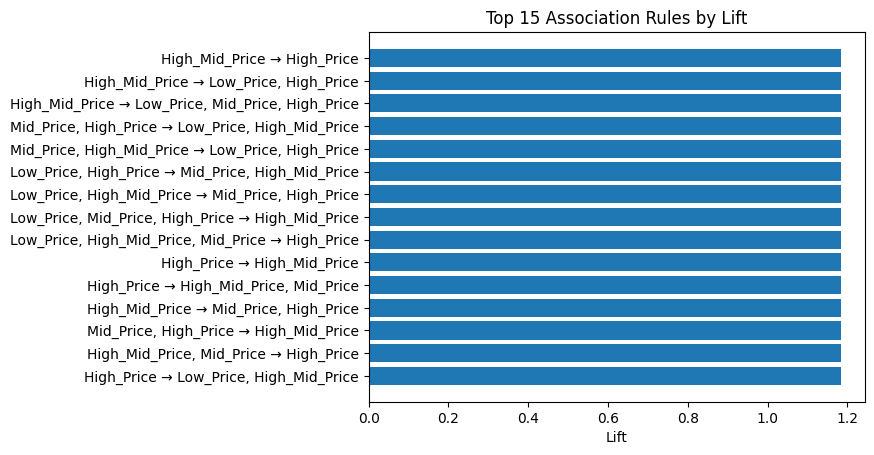

In [17]:
import matplotlib.pyplot as plt

# Create readable rule labels
rules["rule_label"] = (
    rules["antecedents"].apply(lambda x: ", ".join(list(x))) 
    + " → " + 
    rules["consequents"].apply(lambda x: ", ".join(list(x)))
)

# Sort by lift and take top 15
top_rules = rules.sort_values("lift", ascending=False).head(15)

# Single clean plot (no specific colors)
plt.figure()
plt.barh(top_rules["rule_label"], top_rules[""])
plt.xlabel("Lift")
plt.title("Top 15 Association Rules by Lift")
plt.gca().invert_yaxis()
plt.show()